In [8]:
#import danych
import pandas as pd
from plotly.subplots import make_subplots
import plotly.graph_objs as go

In [9]:
#wczytywanie danych csv
kghm = pd.read_csv(r"C:\Users\monia\OneDrive\Pulpit\11.1Zadanie-ceny akcji\kgh_d.csv")
copper = pd.read_csv(r"C:\Users\monia\OneDrive\Pulpit\11.1Zadanie-ceny akcji\ca_c_f_d.csv")

kghm.head()     
copper.head()   


,Data,Otwarcie,Najwyzszy,Najnizszy,Zamkniecie
0,2015-01-02,6309.0,6309.0,6309.0,6309.0
1,2015-01-05,6216.0,6216.0,6216.0,6216.0
2,2015-01-06,6191.0,6191.0,6191.0,6191.0
3,2015-01-07,6170.0,6170.0,6170.0,6170.0
4,2015-01-08,6230.5,6230.5,6230.5,6230.5


In [10]:
#konwersja dat
kghm['Data'] = pd.to_datetime(kghm['Data'])
copper['Data'] = pd.to_datetime(copper['Data'])



In [11]:
#tworzenie tabeli
tabela = pd.DataFrame({
    'Data': kghm['Data'],
    'KGHM': kghm['Zamkniecie'],
    'Miedź': copper['Zamkniecie']
})



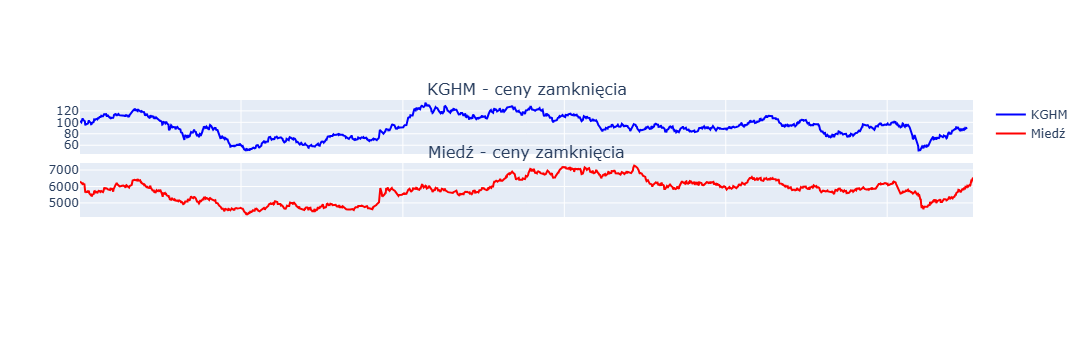

In [12]:
#wykresy
fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    subplot_titles=("KGHM - ceny zamknięcia", "Miedź - ceny zamknięcia")
)

fig.data = []  # czyści trace’y

# wykres KGHM
fig.add_trace(
    go.Scatter(x=kghm['Data'], y=kghm['Zamkniecie'], name="KGHM", line=dict(color='blue')),
    row=1, col=1
)

# wykres Miedź
fig.add_trace(
    go.Scatter(x=copper['Data'], y=copper['Zamkniecie'], name="Miedź", line=dict(color='red')),
    row=2, col=1
)


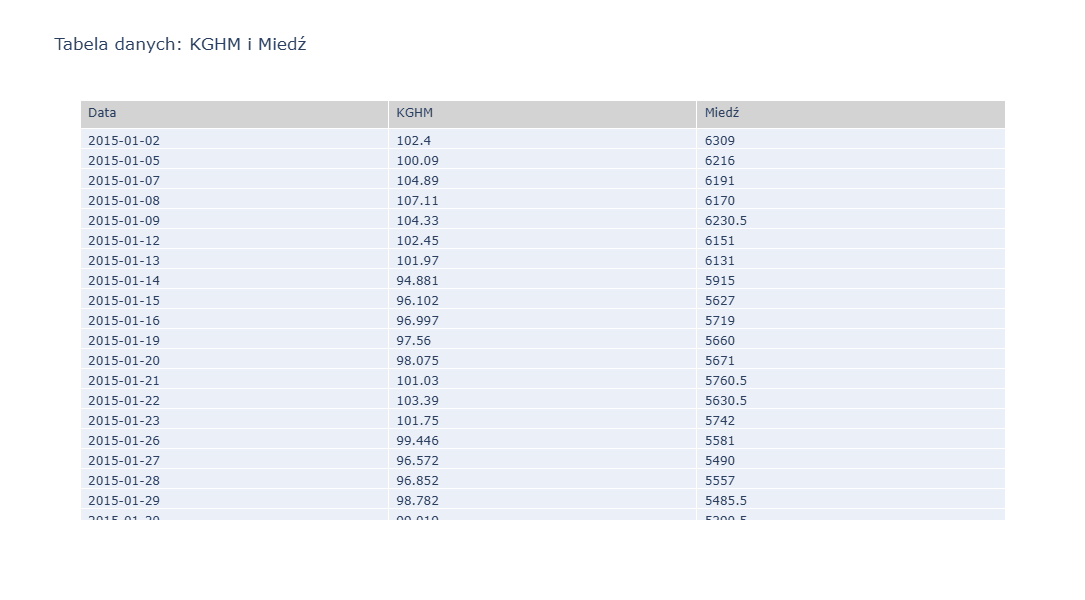

In [13]:
#tabela
fig_table = go.Figure(
    data=[
        go.Table(
            header=dict(
                values=list(tabela.columns),
                fill_color='lightgrey',
                align='left'
            ),
            cells=dict(
                values=[
                    tabela['Data'].dt.strftime('%Y-%m-%d'),  # format daty
                    tabela['KGHM'],
                    tabela['Miedź']
                ],
                align='left'
            )
        )
    ]
)

fig_table.update_layout(
    title="Tabela danych: KGHM i Miedź",
    height=600
)

fig_table.show()
